<a href="https://colab.research.google.com/github/Fa-Alsuqayri/llm_from_scratch/blob/main/arabic_llm_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# !pip install pypdf

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
from datasets import load_dataset


In [3]:

# ds2 = load_dataset("Rabe3/saudi-dialect-rag")

In [ ]:
ds2

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 10022
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1114
    })
})

In [ ]:
small_ds = ds2['train'].select(range(300))

In [ ]:
small_ds[0]

{'instruction': 'أنت سيرا، مساعد ذكي متخصص في أنظمة ولوائح الكهرباء في المملكة العربية السعودية. تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\nالسياق:\nأطلق النادي الرياضي مبادرة خاصة لشهر رمضان المبارك تهدف إلى تيسير تجربة التدريب للصائمين، حيث تم تعديل مواعيد التمارين لتكون بعد صلاة الفجر، وفي وقت العصر، وبعد صلاة التراويح، كما سيقوم النادي بتوفير وجبات إفطار مجانية للمشتركين تتضمن التمر، والشوربة، والسمبوسة، ومشروبات الطاقة.\n\nالمحادثة السابقة:\nالمستخدم: السلام عليكم، ياخي سمعت يقولون انكم بتسوون مبادرات جديدة في رمضان، وش سالفتها؟\nالمساعد: وعليكم السلام، والله صحيح، بنعدل أوقات التمارين وبنوفر وجبات إفطار بعد المغرب.\nالمستخدم: ما شاء الله، طيب وش أوقات التمارين الجديدة؟\nالمساعد: بعد الفجر وعند العصر وبعد التراويح، علشان اللي يصوم يقدر يتدرب مرتاح.\n\nالسؤال: تسلم، وربي انك فكرت في كل شي، بس وش نوع وجبات الإفطار؟',
 'input': '',
 'output': 'بنقدم تمر، شوربة، سمبوسة، ومشروبات طاقة بشكل مجاني.'}

In [ ]:
instruction_data = []

In [ ]:
for row in small_ds:
    instruction_data.append({
        "instruction": row["instruction"],
        "input": row["input"],
        "output": row["output"]
    })

In [ ]:
target_sentence = "أنت سيرا، مساعد ذكي متخصص في أنظمة ولوائح الكهرباء في المملكة العربية السعودية. تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية"
replacement = ""

for row in instruction_data:
    if "instruction" in row and isinstance(row["instruction"], str):
        row["instruction"] = row["instruction"].replace(target_sentence, replacement)

print("تم تنظيف البيانات بنجاح! إليك مثال بعد التعديل:\n")
print(instruction_data[0]['instruction'])

تم تنظيف البيانات بنجاح! إليك مثال بعد التعديل:



السياق:
أطلق النادي الرياضي مبادرة خاصة لشهر رمضان المبارك تهدف إلى تيسير تجربة التدريب للصائمين، حيث تم تعديل مواعيد التمارين لتكون بعد صلاة الفجر، وفي وقت العصر، وبعد صلاة التراويح، كما سيقوم النادي بتوفير وجبات إفطار مجانية للمشتركين تتضمن التمر، والشوربة، والسمبوسة، ومشروبات الطاقة.

المحادثة السابقة:
المستخدم: السلام عليكم، ياخي سمعت يقولون انكم بتسوون مبادرات جديدة في رمضان، وش سالفتها؟
المساعد: وعليكم السلام، والله صحيح، بنعدل أوقات التمارين وبنوفر وجبات إفطار بعد المغرب.
المستخدم: ما شاء الله، طيب وش أوقات التمارين الجديدة؟
المساعد: بعد الفجر وعند العصر وبعد التراويح، علشان اللي يصوم يقدر يتدرب مرتاح.

السؤال: تسلم، وربي انك فكرت في كل شي، بس وش نوع وجبات الإفطار؟


In [ ]:
instruction_data[2]

{'instruction': '\n\nالسياق:\nيتبادل حسين وابن عمه زيد الحديث حول مستويات فرق كرة القدم هذا الموسم، حيث أشادا بأداء نادي الهلال الثابت، بينما عبّر حسين عن تشجيعه لنادي النصر وترقبه لمباراته الحماسية المقررة غداً، وقد اتفق الطرفان على مشاهدة المباراة سوياً في الاستراحة برفقة الأصدقاء.\n\nالمحادثة السابقة:\nالمستخدم: وش رايك بذا الموسم؟ الهلال كويس ولا؟\nالمساعد: والله الهلال دايم كويس. انت وش تشجع؟\n\nالسؤال: أحب النصر، تدري انه بيلعب بكرة؟',
 'input': '',
 'output': 'ايه، والله يقولون المباراة بتكون حماسية. وين بتشوفها؟'}

In [ ]:
import json
with open("/content/more_data.txt", "r", encoding="utf-8") as file:
      text = file.read()

In [ ]:
type(record3)

str

In [ ]:
reader1 = PdfReader('/content/saudia-min.pdf')
reader2 = PdfReader('/content/poetry.pdf')



print(f"Total pages: {len(reader2.pages)}")

Total pages: 96


In [ ]:
text = ""

In [ ]:
for page in reader1.pages:
    text += page.extract_text()


In [ ]:
for page in reader2.pages:
    text += page.extract_text()

In [ ]:

text += record3

In [ ]:
text[0:1000]

'مـوجـز تـأريـخ\nالـدولـة السـعـوديـة\nم)2017هـ1438م1744 هـ1157(8\n9\n«\nالــولاة المتقدميــن والمتأخريــن، ولــم يــزل أهــل العلــم فــي \nكل زمــان يؤرخــون وقائــع الملــوك وأخبارهــم، ويبحثــون عــن \nحــوادث أيامهــم وأعصارهــم\nعثمان بن بشر1011\n مـقــدمــــة 13\nتمهيــد:  الأوضــاع العامــة فــي وســط الجزيرة العربيــة قبيل قيام الدولة الســعودية الأولى \n الحالــة الاجتماعية 17\n الحالــة الاقتصادية 17\n الحالة السياســية 18\n الحالــة الدينيــة والعلمية 19\n أســـــرة آل ســـعــــود 21\n الشــيخ محمــد بــن عبــد الوهاب ودعوته 23\nالدولة الســعودية الأولى \n تأســيس الدولة الســعودية الأولى 29\n مراحــل توحيــد البــاد فــي عهد الدولة الســعودية الأولى 30\n نهايــة الدولة الســعودية الأولى 37\n أئمــة الدولة الســعودية الأولى 39\nقيــام الدولة الســعودية الثانية \n أوضاع الباد في أعقاب ســقوط الدولة الســعودية الأولى 43\n قيــام الدولــة الســعودية الثانية 46\n الإمــام فيصــل بن تركــي (الفترة الأولى 51\n عــودة حكــم الإمــام فيصــل بن تركي (الفتــرة الثانية 57\n النــزاع ب

In [ ]:
len(text)

101378

In [ ]:
text = text[:150000]

In [ ]:
text[:15]

In [ ]:


import os
import urllib.request

import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm


def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params


def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        with urllib.request.urlopen(download_url) as response:
            # Get the total file size from headers, defaulting to 0 if not present
            file_size = int(response.headers.get("Content-Length", 0))

            # Check if file exists and has the same size
            if os.path.exists(destination):
                file_size_local = os.path.getsize(destination)
                if file_size == file_size_local:
                    print(f"File already exists and is up-to-date: {destination}")
                    return True  # Indicate success without re-downloading

            block_size = 1024  # 1 Kilobyte

            # Initialize the progress bar with total file size
            progress_bar_description = os.path.basename(download_url)
            with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
                with open(destination, "wb") as file:
                    while True:
                        chunk = response.read(block_size)
                        if not chunk:
                            break
                        file.write(chunk)
                        progress_bar.update(len(chunk))
            return True

    try:
        if _attempt_download(url):
            return
    except (urllib.error.HTTPError, urllib.error.URLError):
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except urllib.error.HTTPError:
                pass

        # If we reach here, both attempts have failed
        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Alternative way using `requests`
"""
def download_file(url, destination):
    # Send a GET request to download the file in streaming mode
    response = requests.get(url, stream=True)

    # Get the total file size from headers, defaulting to 0 if not present
    file_size = int(response.headers.get("content-length", 0))

    # Check if file exists and has the same size
    if os.path.exists(destination):
        file_size_local = os.path.getsize(destination)
        if file_size == file_size_local:
            print(f"File already exists and is up-to-date: {destination}")
            return

    # Define the block size for reading the file
    block_size = 1024  # 1 Kilobyte

    # Initialize the progress bar with total file size
    progress_bar_description = url.split("/")[-1]  # Extract filename from URL
    with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
        # Open the destination file in binary write mode
        with open(destination, "wb") as file:
            # Iterate over the file data in chunks
            for chunk in response.iter_content(block_size):
                progress_bar.update(len(chunk))  # Update progress bar
                file.write(chunk)  # Write the chunk to the file
"""


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:

import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.tokenizer = tokenizer
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.2,
    "qkv_bias": True
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

print("Downloading and loading OpenAI GPT-2 weights...")
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
load_weights_into_gpt(model, params)

model.eval()
print("Base model loaded successfully! Ready for Fine-tuning.")

Using device: cuda
File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Base model loaded successfully! Ready for Fine-tuning.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

print("Downloading and loading OpenAI GPT-2 weights...")
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
load_weights_into_gpt(model, params)

model.eval()
print("Phase 1 Complete: GPT-2 base model loaded successfully!")

train_ratio = 0.90
split_idx = int(train_ratio * len(text))
train_data = text[:split_idx]
val_data = text[split_idx:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=1,
    max_length=256,
    stride=256,
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=1,
    max_length=256,
    stride=256,
    drop_last=False,
    shuffle=False,
    num_workers=0
)

Using device: cuda
File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Phase 1 Complete: GPT-2 base model loaded successfully!


In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Starting Continued Pretraining on the Arabic PDF...
Ep 1 (Step 000000): Train loss 4.191, Val loss 4.159
Ep 1 (Step 000050): Train loss 2.596, Val loss 2.667
Ep 1 (Step 000100): Train loss 2.436, Val loss 2.525
Ep 1 (Step 000150): Train loss 2.344, Val loss 2.507
Ep 1 (Step 000200): Train loss 2.275, Val loss 2.440
Ep 1 (Step 000250): Train loss 2.259, Val loss 2.326
Ep 1 (Step 000300): Train loss 2.194, Val loss 2.317
Ep 1 (Step 000350): Train loss 2.292, Val loss 2.257
في هذا المستندية الحجازينينينينينينينينينينينينينينينينينينينيني
Ep 2 (Step 000400): Train loss 2.163, Val loss 2.244
Ep 2 (Step 000450): Train loss 2.007, Val loss 2.215
Ep 2 (Step 000500): Train loss 2.149, Val loss 2.249
Ep 2 (Step 000550): Train loss 1.920, Val loss 2.172
Ep 2 (Step 000600): Train loss 1.860, Val loss 2.163
Ep 2 (Step 000650): Train loss 2.011, Val loss 2.180
Ep 2 (Step 000700): Train loss 1.937, Val loss 2.139
في هذا المستندية الحجازية الحجازية، وأحمد بن عبد العزيز بن عبد
Ep 3 (Step 000750): Train

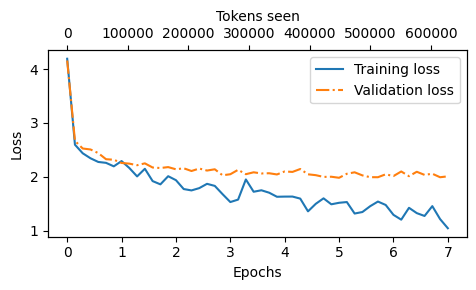

In [ ]:

tokenizer = tiktoken.get_encoding("gpt2")
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs_pdf = 7

print("Starting Continued Pretraining on the Arabic PDF...")

train_losses, val_losses, tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs_pdf,
    eval_freq=50,
    eval_iter=5,
    start_context="في هذا المستند",
    tokenizer=tokenizer
)

torch.save(model.state_dict(), "gpt2_arabic_pretrained.pth")
print("Pretraining on Arabic PDF complete! Model saved.")

epochs_tensor = torch.linspace(0, num_epochs_pdf, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
instruction_data

In [ ]:
import json
with open("history_data_150.json", "r", encoding="utf-8") as f:
    instruction_data = json.load(f)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry.get("input") else ""
    return instruction_text + input_text

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        pad_len = batch_max_length - len(new_item)

        inputs = new_item[:-1] + [pad_token_id] * pad_len
        targets = new_item[1:] + [ignore_index] * pad_len

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.tensor(inputs_lst, device=device)
    targets_tensor = torch.tensor(targets_lst, device=device)

    if allowed_max_length is not None:
        inputs_tensor = inputs_tensor[:, :allowed_max_length]
        targets_tensor = targets_tensor[:, :allowed_max_length]

    return inputs_tensor, targets_tensor


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

train_dataset = InstructionDataset(instruction_data, tokenizer)
train_loader_ft = DataLoader(
    train_dataset,
    batch_size=2,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True
)


optimizer_ft = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs_ft = 7
print("Starting Instruction Fine-Tuning on Saudi Dialect...")

model.train()
for epoch in range(num_epochs_ft):
    total_loss = 0.0
    for step, (input_batch, target_batch) in enumerate(train_loader_ft):
        optimizer_ft.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item()

        if step % 10 == 0:
            print(f"Epoch {epoch+1} | Step {step} | Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} completed. Average Loss: {total_loss / len(train_loader_ft):.4f}")

torch.save(model.state_dict(), "gpt2_saudi_dialect_finetuned.pth")
print("Mission Accomplished! Final Saudi Dialect Model saved.")

Starting Instruction Fine-Tuning on Saudi Dialect...
Epoch 1 | Step 0 | Loss: 3.1244
Epoch 1 | Step 10 | Loss: 2.4011
Epoch 1 | Step 20 | Loss: 1.7431
Epoch 1 | Step 30 | Loss: 1.6795
Epoch 1 | Step 40 | Loss: 1.5641
Epoch 1 | Step 50 | Loss: 1.7624
Epoch 1 completed. Average Loss: 1.9487
Epoch 2 | Step 0 | Loss: 1.4853
Epoch 2 | Step 10 | Loss: 1.2716
Epoch 2 | Step 20 | Loss: 1.9147
Epoch 2 | Step 30 | Loss: 1.4023
Epoch 2 | Step 40 | Loss: 1.4144
Epoch 2 | Step 50 | Loss: 1.5197
Epoch 2 completed. Average Loss: 1.4703
Epoch 3 | Step 0 | Loss: 1.3721
Epoch 3 | Step 10 | Loss: 1.4970
Epoch 3 | Step 20 | Loss: 1.3657
Epoch 3 | Step 30 | Loss: 1.4139
Epoch 3 | Step 40 | Loss: 1.4307
Epoch 3 | Step 50 | Loss: 1.5543
Epoch 3 completed. Average Loss: 1.3515
Epoch 4 | Step 0 | Loss: 1.2796
Epoch 4 | Step 10 | Loss: 1.5728
Epoch 4 | Step 20 | Loss: 1.4363
Epoch 4 | Step 30 | Loss: 1.3317
Epoch 4 | Step 40 | Loss: 1.1750
Epoch 4 | Step 50 | Loss: 1.3374
Epoch 4 completed. Average Loss: 1.2747

In [ ]:
def ask_saudi_model_fixed(question, model, tokenizer, device):
    training_style_instruction = (
        f"انت تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\n"
        f"السياق:\nلا يوجد سياق محدد، أجب من معلوماتك العامة.\n\n"
        f"السؤال: {question}"
    )

    prompt = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{training_style_instruction}"
        f"\n\n### Response:\n"
    )

    input_ids = text_to_token_ids(prompt, tokenizer).to(device)

    model.eval()
    with torch.no_grad():
        output_ids = generate_text_simple(
            model=model,
            idx=input_ids,
            max_new_tokens=50,
            context_size=1024
        )

    generated_text = token_ids_to_text(output_ids, tokenizer)
    response = generated_text.split("### Response:\n")[-1].strip()

    print("-" * 50)
    print(f"الســـؤال : {question}")
    print(f"النمـوذج : {response}")
    print("-" * 50)

ask_saudi_model_fixed("أحب النصر، تدري انه بيلعب بكرة؟", model, tokenizer, device)

--------------------------------------------------
الســـؤال : أحب النصر، تدري انه بيلعب بكرة؟
النمـوذج : النصر السعودية هي أصبحت الأصبح لللحقبة الأحساء.
--------------------------------------------------


In [ ]:
import torch

def generate_text_smart(model, idx, max_new_tokens, context_size, temperature=0.7, top_k=40):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def ask_saudi_model_smart(question, model, tokenizer, device):
    training_style_instruction = (
        f"انت تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\n"
        f"السؤال: {question}"
    )

    prompt = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{training_style_instruction}"
        f"\n\n### Response:\n"
    )

    input_ids = text_to_token_ids(prompt, tokenizer).to(device)

    model.eval()
    with torch.no_grad():

        output_ids = generate_text_smart(
            model=model,
            idx=input_ids,
            max_new_tokens=180,
            context_size=1024,
            temperature=0.3,
            top_k=50
        )

    generated_text = token_ids_to_text(output_ids, tokenizer)
    response = generated_text.split("### Response:\n")[-1].strip()

    print("-" * 50)
    print(f" الســـؤال : {question}")
    print(f" النمـوذج : {response}")
    print("-" * 50)


In [ ]:
ask_saudi_model_smart("من هم الأشراف الذين حكموا الحجاز؟", model, tokenizer, device)


--------------------------------------------------
 الســـؤال : من هم الأشراف الذين حكموا الحجاز؟
 النمـوذج : الأسسسساء الدولة السعودية الأولى (1250- 1309هى)<|endoftext|>المقر
--------------------------------------------------


In [ ]:
ask_saudi_model_smart("ما هو طريق زبيدة وما هي أهميته التاريخية؟", model, tokenizer, device)
ask_saudi_model_smart("تحدث عن سكة حديد الحجاز ومتى تأسست.", model, tokenizer, device)
ask_saudi_model_smart("ما هو سوق عكاظ في تاريخ الحجاز؟", model, tokenizer, device)

--------------------------------------------------
 الســـؤال : ما هو طريق زبيدة وما هي أهميته التاريخية؟
 النمـوذج : قسم المدينة السعودية الأولى (1139هـ - 1250هـ - 1291م)، وأأحدناى عائم المناد الأحد الحداء الجار.<|endoftext|>

###
--------------------------------------------------
--------------------------------------------------
 الســـؤال : تحدث عن سكة حديد الحجاز ومتى تأسست.
 النمـوذج : المملكة العربية السعودية الثانية الحديثة في عام 1187-1291هـ (1191هـ) -1391م)<|endoftext|>المنؤسسس الملك عبر عبدالر الع
--------------------------------------------------
--------------------------------------------------
 الســـؤال : ما هو سوق عكاظ في تاريخ الحجاز؟
 النمـوذج : الدولة السعودية الثانية (1259هـ - 1282هـ)، وتوحيد المنطقة الحجاز، وتأحياء الحجاجاجاجاج الحجاج والحأجاجاجاج الح
--------------------------------------------------


In [ ]:
ask_saudi_model_smart("من هم الأشراف الذين حكموا الحجاز؟", model, tokenizer, device)


--------------------------------------------------
 الســـؤال : من هم الأشراف الذين حكموا الحجاز؟
 النمـوذج : الحجاز هي عام 1139هى المرؤس المرؤسس الحداء الحجاء الذي
--------------------------------------------------


In [ ]:
import math

final_validation_loss = 2.008

perplexity = math.exp(final_validation_loss)

print("-" * 50)
print(f" Model Evaluation Metrics:")
print(f"Final Loss: {final_validation_loss}")
print(f"Perplexity: {perplexity:.2f}")
print("-" * 50)

--------------------------------------------------
 Model Evaluation Metrics:
Final Loss: 2.008
Perplexity: 7.45
--------------------------------------------------


In [ ]:
%%writefile history_data_150.json
[
  {
    "instruction": "من هو مؤسس الدولة السعودية الأولى وما هي عاصمتها؟",
    "input": "",
    "output": "أسس الإمام محمد بن سعود الدولة السعودية الأولى عام 1727م (1139هـ)، وكانت عاصمتها مدينة الدرعية، التي أصبحت مركزاً للاستقرار والازدهار في شبه الجزيرة العربية."
  },
  {
    "instruction": "تحدث باختصار عن العصر الذهبي للدولة العباسية في العصور الوسطى.",
    "input": "",
    "output": "يُعتبر العصر الذهبي للدولة العباسية فترة ازدهار علمي وثقافي واقتصادي غير مسبوق. برزت فيها بغداد كعاصمة للعالم الإسلامي، ونشطت فيها حركة الترجمة وازدهرت المكتبات الكبرى مثل 'بيت الحكمة'."
  },
  {
    "instruction": "متى تم توحيد المملكة العربية السعودية ومن قاد هذا التوحيد؟",
    "input": "",
    "output": "تم إعلان توحيد المملكة العربية السعودية عام 1932م (1351هـ) على يد الملك عبدالعزيز بن عبدالرحمن آل سعود، وذلك بعد ملحمة تاريخية طويلة لتوحيد أجزاء شبه الجزيرة العربية."
  },
  {
    "instruction": "لخص أحداث ونتائج معركة حطين.",
    "input": "وقعت معركة حطين في عام 1187م في العصور الوسطى.",
    "output": "معركة حطين هي معركة فاصلة قادها صلاح الدين الأيوبي ضد الصليبيين. انتهت بانتصار حاسم للمسلمين، مما تسبب في انهيار مملكة بيت المقدس الصليبية ومهد الطريق لاستعادة القدس."
  },
  {
    "instruction": "ما هي أبرز إنجازات الملك عبدالعزيز بعد استرداد الرياض؟",
    "input": "استرد الملك عبدالعزيز الرياض عام 1902م.",
    "output": "بعد استرداد الرياض، انطلق الملك عبدالعزيز في مسيرة لتوحيد مناطق نجد والحجاز والأحساء وعسير. كما قام بتوطين البادية، وبناء مؤسسات الدولة الحديثة، وإرساء الأمن."
  },
  {
    "instruction": "ما هو دور الأندلس في نقل المعرفة إلى أوروبا خلال العصور الوسطى؟",
    "input": "",
    "output": "لعبت الأندلس دوراً محورياً في نقل العلوم والفلسفة والطب إلى أوروبا. كانت مدن مثل قرطبة وطليطلة مراكز للترجمة، حيث توافد الطلاب الأوروبيون لنهل المعرفة من العلماء المسلمين."
  },
  {
    "instruction": "اذكر نبذة عن معركة فتح الرياض وأهميتها التاريخية.",
    "input": "",
    "output": "حدثت معركة فتح الرياض عام 1319هـ (1902م)، حينما تمكن الملك عبدالعزيز ورجاله من استرداد مدينة الرياض. تُعد هذه المعركة نقطة التحول الكبرى لتأسيس المملكة الحديثة."
  },
  {
    "instruction": "من هو الإمام تركي بن عبدالله وما هو دوره التاريخي؟",
    "input": "",
    "output": "الإمام تركي بن عبدالله هو مؤسس الدولة السعودية الثانية. تمكن من استعادة السيطرة وتوحيد الصفوف بعد سقوط الدرعية، واتخذ من مدينة الرياض عاصمة جديدة للدولة."
  },
  {
    "instruction": "صف معركة عين جالوت وأهميتها في العصور الوسطى.",
    "input": "",
    "output": "وقعت عين جالوت عام 1260م بقيادة السلطان قطز والظاهر بيبرس ضد المغول. انتهت بانتصار ساحق للمسلمين، وأوقفت الزحف المغولي الذي دمر بغداد، وأنقذت الحضارة الإسلامية من الانهيار."
  },
  {
    "instruction": "متى سقطت الدولة الأموية وكيف تأسست الدولة الأموية في الأندلس؟",
    "input": "",
    "output": "سقطت الخلافة الأموية في دمشق عام 750م على يد العباسيين. لاحقاً، تمكن عبدالرحمن الداخل (صقر قريش) من الفرار إلى الأندلس وتأسيس دولة أموية جديدة ومستقلة هناك في قرطبة."
  },
  {
    "instruction": "ما هي معركة طليطلة ومتى سقطت؟",
    "input": "",
    "output": "سقطت مدينة طليطلة الأندلسية عام 1085م في أيدي الممالك المسيحية (ألفونسو السادس)، وكان سقوطها بداية فعلية لسلسلة تراجع الوجود الإسلامي في شبه الجزيرة الأيبيرية."
  },
  {
    "instruction": "ما هو حي الطريف في الدرعية؟",
    "input": "",
    "output": "حي الطريف هو الحي التاريخي الأهم في مدينة الدرعية، وكان مقراً للحكم والأسرة المالكة في الدولة السعودية الأولى. يضم قصوراً تاريخية ومساجد، وهو اليوم موقع مسجل في قائمة التراث العالمي لليونسكو."
  },
  {
    "instruction": "اذكر دور الخليفة هارون الرشيد في العصور الوسطى.",
    "input": "",
    "output": "يُعد هارون الرشيد من أشهر خلفاء الدولة العباسية. في عهده بلغت الدولة أوج قوتها العسكرية وازدهارها الاقتصادي، واهتم بالعلوم والترجمة، ووسّع 'بيت الحكمة' في بغداد."
  },
  {
    "instruction": "كيف ساهم توطين البادية (الهجر) في بناء الدولة السعودية الحديثة؟",
    "input": "",
    "output": "مشروع 'الهجر' الذي أطلقه الملك عبدالعزيز هدف إلى توطين البدو الرحل في قرى زراعية مستقرة، مما ساهم في نشر التعليم، وتوحيد الصفوف، وتكوين قوة وطنية مساندة في معارك توحيد المملكة."
  },
  {
    "instruction": "ما هي معركة الزلاقة؟",
    "input": "",
    "output": "معركة الزلاقة وقعت عام 1086م في الأندلس، بقيادة يوسف بن تاشفين أمير المرابطين ضد القوات القشتالية. أسفرت عن انتصار عظيم للمسلمين أطال عمر الوجود الإسلامي في الأندلس لقرون."
  },
  {
    "instruction": "ما هو دور قصر المسمك في تاريخ الرياض؟",
    "input": "",
    "output": "قصر المصمك هو حصن تاريخي يقع في قلب الرياض. ارتبط اسمه ارتباطاً وثيقاً بملحمة فتح الرياض عام 1902م، حيث استرده الملك عبدالعزيز، ليكون نقطة الانطلاق لتأسيس المملكة."
  },
  {
    "instruction": "من هو السلطان محمد الفاتح وما هو إنجازه الأكبر؟",
    "input": "",
    "output": "محمد الفاتح هو سابع سلاطين الدولة العثمانية. إنجازه الأعظم هو فتح مدينة القسطنطينية (إسطنبول حالياً) عام 1453م، مما أنهى الإمبراطورية البيزنطية وفتح صفحة جديدة في العصور الوسطى."
  },
  {
    "instruction": "تحدث عن اكتشاف النفط في المملكة العربية السعودية.",
    "input": "",
    "output": "تم اكتشاف النفط بكميات تجارية في المملكة عام 1938م في بئر الدمام رقم 7 (بئر الخير). أحدث هذا الاكتشاف نقلة نوعية هائلة في الاقتصاد السعودي وساهم في النهضة العمرانية والتنموية الشاملة."
  },
  {
    "instruction": "من هو ابن خلدون وما هو أشهر مؤلفاته؟",
    "input": "",
    "output": "ابن خلدون هو عالم ومؤرخ مسلم عاش في العصور الوسطى، ويُعتبر مؤسس علم الاجتماع الحديث. أشهر مؤلفاته هو كتاب 'المقدمة' الذي وضع فيه أسس العمران البشري وتطور المجتمعات والدول."
  },
  {
    "instruction": "ما هي أبرز التحديات التي واجهت الدولة السعودية الثانية؟",
    "input": "",
    "output": "واجهت الدولة السعودية الثانية تحديات عديدة شملت التدخلات الخارجية من القوات العثمانية في مصر، والنزاعات الداخلية بين بعض أفراد الأسرة الحاكمة، مما أدى في النهاية إلى انتهائها عام 1891م."
  },
  {
    "instruction": "ماذا تعرف عن الحروب الصليبية في العصور الوسطى؟",
    "input": "",
    "output": "الحروب الصليبية هي سلسلة من الحملات العسكرية التي شنتها الممالك الأوروبية المسيحية نحو المشرق الإسلامي بين القرنين الحادي عشر والثالث عشر، بهدف السيطرة على القدس والأراضي المقدسة."
  },
  {
    "instruction": "من هم المرابطون والموحدون في تاريخ المغرب والأندلس؟",
    "input": "",
    "output": "المرابطون والموحدون هما دولتان إسلاميتان قويتان نشأتا في شمال أفريقيا (المغرب الكبير) خلال العصور الوسطى، وعبرتا إلى الأندلس لإنقاذها من سقوط الممالك الإسلامية والدفاع عنها ضد الممالك المسيحية."
  },
  {
    "instruction": "ما هو دور الملك سعود بن عبدالعزيز في التعليم؟",
    "input": "",
    "output": "شهد عهد الملك سعود بن عبدالعزيز طفرة في التعليم، حيث تم تأسيس أول جامعة في شبه الجزيرة العربية وهي جامعة الملك سعود بالرياض عام 1957م، بالإضافة إلى التوسع في إنشاء المدارس والمعاهد."
  },
  {
    "instruction": "من هو ابن سينا وما هي أبرز إسهاماته؟",
    "input": "",
    "output": "ابن سينا هو طبيب وفيلسوف وعالم مسلم برز في العصور الوسطى. يُعرف بلقب 'الشيخ الرئيس'، وأشهر مؤلفاته كتاب 'القانون في الطب' الذي ظل المرجع الطبي الأساسي في أوروبا لعدة قرون."
  },
  {
    "instruction": "ما هي معركة العقير في تاريخ توحيد المملكة؟",
    "input": "",
    "output": "العقير هو ميناء تاريخي في الأحساء، وشهد توقيع معاهدة العقير عام 1922م بين الملك عبدالعزيز والحكومة البريطانية، والتي تم بموجبها ترسيم الحدود بين نجد والعراق والكويت."
  },
  {
    "instruction": "كيف سقطت بغداد في أيدي المغول؟",
    "input": "",
    "output": "سقطت بغداد عام 1258م على يد الجيوش المغولية بقيادة هولاكو. انتهى هذا السقوط بتدمير المدينة، وقتل الخليفة العباسي المستعصم بالله، وحرق مكتباتها ورمي كتبها في نهر دجلة."
  },
  {
    "instruction": "من هو الإمام عبدالله بن سعود؟",
    "input": "",
    "output": "الإمام عبدالله بن سعود هو آخر أئمة الدولة السعودية الأولى. قاد الدفاع البطولي عن مدينة الدرعية ضد الحملات العثمانية بقيادة إبراهيم باشا، وانتهى حكمه بسقوط الدرعية عام 1818م."
  },
  {
    "instruction": "ما هي معركة وادي الصفراء؟",
    "input": "",
    "output": "معركة وادي الصفراء وقعت عام 1812م، وفيها تصدت القوات السعودية الأولى ببسالة لحملة طوسون باشا العثمانية ونجحت في إلحاق هزيمة قاسية بها في بدايات الصراع."
  },
  {
    "instruction": "ما هو دور الخوارزمي في تقدم الرياضيات في العصور الوسطى؟",
    "input": "",
    "output": "الخوارزمي هو عالم مسلم أسس علم الجبر. قدم الأرقام الهندية العربية إلى العالم، ووضع مصطلح 'الخوارزميات' (Algorithms) الذي يُعد الأساس لعلوم الحاسب الآلي والبرمجة الحديثة."
  },
  {
    "instruction": "من هو الملك فيصل بن عبدالعزيز وما هي أبرز مواقفه؟",
    "input": "",
    "output": "الملك فيصل هو ثالث ملوك المملكة. عُرف بحكمته وحنكته السياسية، ومن أبرز مواقفه التضامن الإسلامي، واستخدام النفط كسلاح خلال حرب 1973م للضغط على الدول الداعمة لإسرائيل."
  },
  {
    "instruction": "ما هو نظام الحسبة في العصور الوسطى الإسلامية؟",
    "input": "",
    "output": "الحسبة هي وظيفة دينية واجتماعية وإدارية في الدولة الإسلامية، يتولاها 'المحتسب' لمراقبة الأسواق، ومنع الغش والتطفيف في المكاييل، وضمان الآداب العامة والحفاظ على النظام."
  },
  {
    "instruction": "ماذا تعرف عن مكتبة قرطبة في الأندلس؟",
    "input": "",
    "output": "مكتبة قرطبة أسسها الخليفة الحكم المستنصر بالله في الأندلس، وكانت من أعظم مكتبات العصور الوسطى، حيث احتوت على مئات الآلاف من المجلدات والمخطوطات النادرة في مختلف العلوم."
  },
  {
    "instruction": "كيف اهتمت المملكة العربية السعودية بتوسعة الحرمين الشريفين؟",
    "input": "",
    "output": "منذ عهد الملك عبدالعزيز وحتى اليوم، تولي المملكة توسعة المسجد الحرام والمسجد النبوي أولوية قصوى، من خلال مشاريع هندسية ضخمة تهدف إلى زيادة الطاقة الاستيعابية وتوفير الراحة للحجاج والمعتمرين."
  },
  {
    "instruction": "من هو الفيلسوف ابن رشد؟",
    "input": "",
    "output": "ابن رشد هو فيلسوف وطبيب وقاضٍ أندلسي مسلم. اشتهر بشروحاته العميقة لفلسفة أرسطو، وكان لفكره تأثير هائل على الفكر الأوروبي خلال أواخر العصور الوسطى وعصر النهضة."
  },
  {
    "instruction": "ما هي الدرعية وما هي أهميتها التاريخية؟",
    "input": "",
    "output": "الدرعية هي العاصمة الأولى للدولة السعودية، تقع على ضفاف وادي حنيفة. انطلقت منها دعوة الإصلاح والتوحيد، وتمثل الرمز التاريخي لانطلاق الدولة السعودية وتأسيسها عام 1727م."
  },
  {
    "instruction": "تحدث عن الدولة الفاطمية وعاصمتها.",
    "input": "",
    "output": "الدولة الفاطمية هي دولة إسلامية نشأت في شمال أفريقيا ثم انتقلت إلى مصر. أسس الفاطميون مدينة القاهرة لتكون عاصمة لهم، وبنوا فيها الجامع الأزهر الذي أصبح منارة علمية كبرى."
  },
  {
    "instruction": "ما هي أبرز جهود الملك فهد بن عبدالعزيز في خدمة الإسلام؟",
    "input": "",
    "output": "تبنى الملك فهد بن عبدالعزيز لقب 'خادم الحرمين الشريفين'، وشهد عهده أضخم توسعة تاريخية للحرمين، بالإضافة إلى إنشاء مجمع الملك فهد لطباعة المصحف الشريف في المدينة المنورة."
  },
  {
    "instruction": "من هو الظاهر بيبرس؟",
    "input": "",
    "output": "الظاهر بيبرس هو من أبرز سلاطين المماليك. كان له دور حاسم في معركة عين جالوت ضد المغول، وقاد حملات عسكرية ناجحة ضد الصليبيين، وساهم في إعادة إحياء الخلافة العباسية في القاهرة."
  },
  {
    "instruction": "متى تأسست جامعة الدول العربية وما دور المملكة فيها؟",
    "input": "",
    "output": "تأسست جامعة الدول العربية عام 1945م، وكانت المملكة العربية السعودية بقيادة الملك عبدالعزيز من الدول السبع المؤسسة لها، مؤكدة على دورها الريادي في دعم التضامن والعمل العربي المشترك."
  },
  {
    "instruction": "ما هي معركة البكيرية؟",
    "input": "",
    "output": "معركة البكيرية وقعت عام 1904م بين قوات الملك عبدالعزيز وقوات ابن رشيد المدعومة من العثمانيين في القصيم. انتهت المعركة بانتصار القوات السعودية وتثبيت حكم الملك عبدالعزيز في المنطقة."
  },
  {
    "instruction": "ما هو البيمارستان في العصور الوسطى؟",
    "input": "",
    "output": "البيمارستان هو مصطلح فارسي الأصل يُطلق على المستشفيات في الحضارة الإسلامية. كانت البيمارستانات مراكز متقدمة للعلاج الطبي السريري وتعليم الطب، وتقدم خدماتها للمرضى مجاناً."
  },
  {
    "instruction": "من هو الرحالة ابن بطوطة؟",
    "input": "",
    "output": "ابن بطوطة هو أعظم رحالة مسلم في العصور الوسطى. قضى حوالي ثلاثين عاماً في السفر والترحال عبر العالم الإسلامي وخارجه، ووثّق رحلاته في كتابه الشهير 'تحفة النظار في غرائب الأمصار'."
  },
  {
    "instruction": "اذكر نبذة عن تأسيس مجلس التعاون الخليجي.",
    "input": "",
    "output": "تأسس مجلس التعاون لدول الخليج العربية عام 1981م بمبادرة وجهود كبيرة من المملكة العربية السعودية (في عهد الملك خالد)، ويهدف إلى تحقيق التنسيق والتكامل والترابط بين دول الخليج في كافة الميادين."
  },
  {
    "instruction": "كيف انتهت دولة المماليك؟",
    "input": "",
    "output": "انتهت دولة المماليك عام 1517م بعد هزيمتهم أمام الجيوش العثمانية بقيادة السلطان سليم الأول في معركة الريدانية، مما أدى إلى ضم مصر والشام والحجاز إلى الإمبراطورية العثمانية."
  },
  {
    "instruction": "ما هي معركة روضة مهنا؟",
    "input": "",
    "output": "معركة روضة مهنا وقعت عام 1906م، وفيها حقق الملك عبدالعزيز انتصاراً حاسماً أدى إلى مقتل عبدالعزيز بن متعب بن رشيد، مما أرسى سيطرة الدولة السعودية على منطقة القصيم بالكامل."
  },
  {
    "instruction": "ما هي الهندسة المعمارية الإسلامية في الأندلس؟",
    "input": "",
    "output": "تميزت العمارة الأندلسية بالأقواس المزدوجة، والنقوش الجصية، والزخارف الهندسية المعقدة، والساحات المفتوحة. من أبرز شواهدها الخالدة قصر الحمراء في غرناطة ومسجد قرطبة الكبير."
  },
  {
    "instruction": "من هو الإمام سعود بن عبدالعزيز (سعود الكبير)؟",
    "input": "",
    "output": "الإمام سعود الكبير هو أحد أبرز أئمة الدولة السعودية الأولى. في عهده وصلت الدولة إلى أقصى اتساع جغرافي لها، حيث شملت نجد والحجاز والأحساء وأجزاء من عمان واليمن وعسير."
  },
  {
    "instruction": "تحدث عن الفتوحات الإسلامية في بلاد ما وراء النهر.",
    "input": "",
    "output": "قاد القائد المسلم قتيبة بن مسلم الباهلي الفتوحات في بلاد ما وراء النهر (آسيا الوسطى) خلال العصر الأموي، ففتح مدناً تاريخية عظيمة مثل بخارى وسمرقند، التي أصبحت لاحقاً مراكز للإشعاع الحضاري."
  },
  {
    "instruction": "ما هو مجلس الشورى السعودي ومتى تأسس؟",
    "input": "",
    "output": "مجلس الشورى هو هيئة استشارية تنظيمية في المملكة. أرسى الملك عبدالعزيز دعائمه الأولى بعد توحيد الحجاز عام 1926م، وتم تطويره في عهد الملك فهد عام 1992م ليواكب التطورات الحديثة."
  },
  {
    "instruction": "ما هي معركة ملاذكرد وأهميتها؟",
    "input": "",
    "output": "معركة ملاذكرد وقعت عام 1071م بين السلاجقة بقيادة ألب أرسلان والإمبراطورية البيزنطية. انتهت بانتصار السلاجقة وفتح أبواب الأناضول (تركيا الحالية) أمام الوجود الإسلامي والتركي."
  },
  {
    "instruction": "ما هي مبادرة رؤية المملكة 2030 وكيف ترتبط بالتاريخ؟",
    "input": "",
    "output": "رؤية 2030 هي خطة تنموية شاملة. ترتبط بالتاريخ من خلال تركيزها على إحياء التراث الوطني، مثل تطوير 'بوابة الدرعية' التاريخية ومحافظة العُلا، لربط جذور الماضي الأصيل بمستقبل المملكة المشرق."
  },
  {
    "instruction": "من هو طارق بن زياد؟",
    "input": "",
    "output": "طارق بن زياد هو قائد عسكري مسلم شهير، قاد الجيوش الإسلامية لفتح الأندلس عام 711م في عهد الدولة الأموية. سُمي 'مضيق جبل طارق' تيمناً به بعد عبوره إلى شبه الجزيرة الأيبيرية."
  },
  {
    "instruction": "ما هو دور المملكة في تأسيس منظمة أوبك؟",
    "input": "",
    "output": "لعبت المملكة العربية السعودية دوراً قيادياً وتأسيسياً في إنشاء منظمة الدول المصدرة للنفط (أوبك) عام 1960م، بهدف تنسيق السياسات النفطية وحماية استقرار أسواق الطاقة العالمية."
  },
  {
    "instruction": "ماذا تعرف عن معركة بواتييه (بلاط الشهداء)؟",
    "input": "",
    "output": "معركة بلاط الشهداء وقعت عام 732م في فرنسا بين الجيش الإسلامي بقيادة عبدالرحمن الغافقي وجيش الفرنجة بقيادة شارل مارتل. انتهت بتوقف التمدد الإسلامي في غرب أوروبا واستشهاد الغافقي."
  },
  {
    "instruction": "من هو الإمام فيصل بن تركي؟",
    "input": "",
    "output": "الإمام فيصل بن تركي هو من أبرز أئمة الدولة السعودية الثانية. استطاع استعادة الحكم والرياض بعد أسره في مصر، ووطد دعائم الاستقرار والأمن في مناطق نجد والأحساء."
  },
  {
    "instruction": "ما هو العصر المملوكي؟",
    "input": "",
    "output": "العصر المملوكي هو فترة حكمت فيها طبقة العسكر (المماليك) مصر والشام والحجاز. تميزوا بقوتهم العسكرية التي دحرت المغول والصليبيين، وشيدوا نهضة معمارية وعلمية كبرى في القاهرة ودمشق."
  },
  {
    "instruction": "كيف تم توحيد الحجاز مع نجد؟",
    "input": "",
    "output": "تمكن الملك عبدالعزيز من ضم الحجاز السلمي عام 1925م بعد خروج الشريف علي بن الحسين. بعدها بُويع ملكاً على الحجاز وسلطاناً على نجد وملحقاتها، مما مهد لإعلان المملكة العربية السعودية."
  },
  {
    "instruction": "من هو جابر بن حيان؟",
    "input": "",
    "output": "جابر بن حيان هو عالم مسلم يُلقب بـ 'أبو الكيمياء'. في العصور الوسطى المبكرة، أسس المنهج التجريبي في الكيمياء، واخترع عمليات كيميائية هامة مثل التقطير والتبلور، واكتشف العديد من الأحماض."
  },
  {
    "instruction": "ما هو يوم التأسيس السعودي؟",
    "input": "",
    "output": "يوم التأسيس يوافق 22 فبراير من كل عام، وهو يخلد ذكرى تأسيس الدولة السعودية الأولى على يد الإمام محمد بن سعود عام 1727م في الدرعية، اعتزازاً بالجذور الراسخة والتاريخ العريق للدولة."
  },
  {
    "instruction": "من هو الإدريسي وما هو إسهامه في علم الجغرافيا؟",
    "input": "",
    "output": "الإدريسي هو عالم جغرافيا مسلم في العصور الوسطى. وضع خريطة دقيقة للعالم تُعرف بـ 'لوح الترسيم'، وألف كتابه الشهير 'نزهة المشتاق في اختراق الآفاق' الذي اعتمدت عليه أوروبا لقرون."
  },
  {
    "instruction": "ما هي معركة السبلة؟",
    "input": "",
    "output": "معركة السبلة وقعت عام 1929م بين قوات الملك عبدالعزيز وبعض قادة الإخوان الذين تمردوا على سلطة الدولة. انتهت بانتصار الملك عبدالعزيز وفرض سلطة الدولة المركزية والنظام."
  },
  {
    "instruction": "تحدث عن سقوط غرناطة.",
    "input": "",
    "output": "سقطت غرناطة، آخر معاقل المسلمين في الأندلس، عام 1492م بعد حصار طويل من قِبل الملكين الكاثوليكيين فرديناند وإيزابيلا، وبذلك انتهى الوجود الإسلامي السياسي في شبه الجزيرة الأيبيرية."
  },
  {
    "instruction": "ما هو دور الملك عبدالله بن عبدالعزيز في التنمية؟",
    "input": "",
    "output": "شهد عهد الملك عبدالله طفرة اقتصادية وتعليمية كبرى، شملت إطلاق برنامج خادم الحرمين الشريفين للابتعاث الخارجي، وتأسيس جامعة الملك عبدالله للعلوم والتقنية (KAUST)، وإنشاء المدن الاقتصادية."
  },
  {
    "instruction": "ما هي معركة ذات الصواري؟",
    "input": "",
    "output": "معركة ذات الصواري هي أول معركة بحرية كبرى في التاريخ الإسلامي، وقعت عام 655م (34هـ) ضد الأسطول البيزنطي، وانتهت بانتصار المسلمين وسيطرتهم على الملاحة في البحر الأبيض المتوسط."
  },
  {
    "instruction": "من هو الملك خالد بن عبدالعزيز؟",
    "input": "",
    "output": "الملك خالد هو رابع ملوك المملكة. اتسم عهده بالرخاء الاقتصادي والتنمية الشاملة بفضل ارتفاع عوائد النفط، وتم في عهده إنجاز مشاريع ضخمة في البنية التحتية، وتأسيس الهيئة الملكية للجبيل وينبع."
  },
  {
    "instruction": "ما هي إسهامات المسلمين في علم الفلك خلال العصور الوسطى؟",
    "input": "",
    "output": "بنى المسلمون المراصد الفلكية، وطوروا آلة 'الأسطرلاب' لتحديد المواقع والاتجاهات، وصححوا حسابات بطليموس. من أبرز العلماء البتاني والصوفي اللذان وضعا فهارس دقيقة لحركة النجوم والكواكب."
  },
  {
    "instruction": "ما هو اليوم الوطني السعودي؟",
    "input": "",
    "output": "اليوم الوطني يوافق 23 سبتمبر من كل عام، وهو يخلد ذكرى المرسوم الملكي الذي أصدره الملك عبدالعزيز عام 1932م القاضي بتوحيد البلاد وتغيير اسمها إلى 'المملكة العربية السعودية'."
  },
  {
    "instruction": "من هو ابن النفيس؟",
    "input": "",
    "output": "ابن النفيس هو طبيب مسلم عاش في العصر المملوكي. إنجازه الأعظم هو اكتشاف 'الدورة الدموية الصغرى' (دوران الدم بين القلب والرئتين)، وهو اكتشاف سبق به العلماء الأوروبيين بعدة قرون."
  },
  {
    "instruction": "ما هو صندوق الاستثمارات العامة (PIF)؟",
    "input": "",
    "output": "تأسس صندوق الاستثمارات العامة عام 1971م. وهو اليوم يمثل المحرك الأساسي للاقتصاد والاستثمار في المملكة ضمن رؤية 2030، ويهدف لتنويع مصادر الدخل الوطني وبناء مشاريع عملاقة مثل 'نيوم'."
  },
  {
    "instruction": "كيف دخل الإسلام إلى الهند والسند؟",
    "input": "",
    "output": "بدأ دخول الإسلام إلى بلاد السند في العصر الأموي عبر حملة عسكرية ناجحة قادها القائد الشاب محمد بن القاسم الثقفي، مما مهد لانتشار الإسلام لاحقاً في شبه القارة الهندية."
  },
  {
    "instruction": "تحدث عن ولاية العهد في عهد الملك سلمان بن عبدالعزيز.",
    "input": "",
    "output": "في عهد الملك سلمان بن عبدالعزيز، تم تعيين الأمير محمد بن سلمان ولياً للعهد. قاد ولي العهد إصلاحات هيكلية واقتصادية واجتماعية جذرية غير مسبوقة، وأطلق رؤية المملكة 2030 لمرحلة ما بعد النفط."
  },
  {
    "instruction": "ما هي المدرسة النظامية؟",
    "input": "",
    "output": "المدارس النظامية هي مؤسسات تعليمية أسسها الوزير السلجوقي نظام الملك في بغداد وغيرها من المدن خلال العصور الوسطى. كانت توفر التعليم المجاني والسكن للطلاب، وتُعد أولى الجامعات الحقيقية في التاريخ."
  },
  {
    "instruction": "ما هو دور المملكة في خدمة القضية الفلسطينية عبر التاريخ؟",
    "input": "",
    "output": "منذ عهد الملك عبدالعزيز، تعتبر المملكة الداعم السياسي والمادي الأكبر للقضية الفلسطينية في المحافل الدولية، ورفضت الاحتلال الإسرائيلي، وقدمت مبادرة السلام العربية عام 2002م (مبادرة الملك عبدالله)."
  },
  {
    "instruction": "من هو صلاح الدين الأيوبي؟",
    "input": "",
    "output": "صلاح الدين الأيوبي هو قائد عسكري فذ ومؤسس الدولة الأيوبية. استطاع توحيد مصر والشام، وقاد المسلمين للانتصار في معركة حطين عام 1187م، واسترداد مدينة القدس من أيدي الصليبيين بأخلاق الفروسية والتسامح."
  },
  {
    "instruction": "كيف نشأت مدينة نيوم (NEOM)؟",
    "input": "",
    "output": "أطلق ولي العهد الأمير محمد بن سلمان مشروع 'نيوم' عام 2017م كجزء من رؤية 2030. هي مدينة ذكية عملاقة شمال غرب المملكة، تعتمد بالكامل على الطاقة المتجددة وتهدف لتكون نموذجاً لمستقبل البشرية."
  },
  {
    "instruction": "من هو مؤسس الدولة السعودية الأولى وما هي عاصمتها؟",
    "input": "",
    "output": "أسس الإمام محمد بن سعود الدولة السعودية الأولى في عام 1727م (1139هـ)، وكانت عاصمتها مدينة الدرعية، والتي أصبحت مركزاً للاستقرار والازدهار في شبه الجزيرة العربية."
  },
  {
    "instruction": "تحدث باختصار عن العصر الذهبي للدولة العباسية في العصور الوسطى.",
    "input": "",
    "output": "يُعتبر العصر الذهبي للدولة العباسية فترة ازدهار علمي وثقافي واقتصادي غير مسبوق. برزت فيها بغداد كعاصمة للعالم الإسلامي، ونشطت فيها حركة الترجمة وازدهرت المكتبات الكبرى مثل 'بيت الحكمة'."
  },
  {
    "instruction": "متى تم توحيد المملكة العربية السعودية ومن قاد هذا التوحيد؟",
    "input": "",
    "output": "تم إعلان توحيد المملكة العربية السعودية في عام 1932م (1351هـ) على يد الملك عبدالعزيز بن عبدالرحمن آل سعود، وذلك بعد ملحمة تاريخية طويلة لتوحيد أجزاء شبه الجزيرة العربية وإرساء الأمن فيها."
  },
  {
    "instruction": "لخص أحداث ونتائج معركة حطين.",
    "input": "وقعت معركة حطين في عام 1187م في العصور الوسطى.",
    "output": "معركة حطين هي معركة فاصلة قادها القائد المسلم صلاح الدين الأيوبي ضد الصليبيين. انتهت المعركة بانتصار حاسم للمسلمين، مما تسبب في انهيار مملكة بيت المقدس الصليبية ومهد الطريق لاستعادة مدينة القدس."
  },
  {
    "instruction": "ما هي أبرز إنجازات الملك عبدالعزيز بعد استرداد الرياض؟",
    "input": "استرد الملك عبدالعزيز الرياض عام 1902م.",
    "output": "بعد استرداد الرياض، انطلق الملك عبدالعزيز في مسيرة لتوحيد مناطق نجد والحجاز والأحساء وعسير وغيرها. كما قام بتوطين البادية، وبناء مؤسسات الدولة الحديثة، وإرساء دعائم الأمن والاستقرار في كافة أرجاء البلاد."
  },
  {
    "instruction": "ما هو دور الأندلس في نقل المعرفة إلى أوروبا خلال العصور الوسطى؟",
    "input": "",
    "output": "لعبت الأندلس دوراً محورياً في نقل العلوم والفلسفة والطب إلى أوروبا المظلمة في العصور الوسطى. كانت مدن مثل قرطبة وطليطلة مراكز للترجمة والتعلم، حيث توافد إليها الطلاب الأوروبيون لنهل المعرفة من العلماء المسلمين."
  },
  {
    "instruction": "اذكر نبذة عن معركة فتح الرياض وأهميتها التاريخية.",
    "input": "",
    "output": "حدثت معركة فتح الرياض في الخامس من شوال عام 1319هـ (1902م)، حينما تمكن الملك عبدالعزيز ورجاله من استرداد مدينة الرياض. تُعد هذه المعركة نقطة التحول الكبرى والانطلاقة الحقيقية لتأسيس المملكة العربية السعودية الحديثة."
  },
  {
    "instruction": "ما هو طريق زبيدة وما هي أهميته التاريخية؟",
    "input": "",
    "output": "طريق زبيدة هو طريق حج تاريخي يربط بين الكوفة في العراق ومكة المكرمة. أُنشئ في العصر العباسي ونُسب إلى السيدة زبيدة زوجة هارون الرشيد التي أمرت بتوفير الآبار والاستراحات لخدمة الحجاج."
  },
  {
    "instruction": "تحدث عن سكة حديد الحجاز ومتى تأسست.",
    "input": "",
    "output": "سكة حديد الحجاز هي خط قطار تاريخي تأسس عام 1908م في عهد السلطان عبدالحميد الثاني، وكان يربط بين دمشق والمدينة المنورة لتسهيل رحلة الحج، لكنه دُمر خلال الحرب العالمية الأولى."
  },
  {
    "instruction": "ما هي معركة تربة التاريخية؟",
    "input": "",
    "output": "معركة تربة وقعت عام 1919م بين قوات الملك عبدالعزيز وقوات الشريف حسين بن علي. انتهت بانتصار حاسم لقوات الملك عبدالعزيز، وكانت خطوة مهمة مهدت الطريق لاحقاً لضم الحجاز."
  },
  {
    "instruction": "أين يقع قصر شبرا وما هي مكانته التاريخية؟",
    "input": "",
    "output": "يقع قصر شبرا في مدينة الطائف، وبُني عام 1904م. يتميز بتصميمه المعماري الفريد الذي يدمج الطابع الروماني والإسلامي، وكان مقراً لإقامة الملك عبدالعزيز والملك فيصل عند زيارتهم للطائف."
  },
  {
    "instruction": "ما هو سوق عكاظ في تاريخ الحجاز؟",
    "input": "",
    "output": "سوق عكاظ هو أشهر أسواق العرب في الجاهلية وصدر الإسلام، يقع بالقرب من الطائف. لم يكن مجرد سوق تجاري، بل كان منبراً ثقافياً وأدبياً تُلقى فيه القصائد وتُعقد فيه المعاهدات."
  },
  {
    "instruction": "تحدث عن الدولة الأخيضرية في تاريخ نجد.",
    "input": "",
    "output": "الدولة الأخيضرية هي إمارة إسلامية استقلت في إقليم اليمامة (نجد) في منتصف القرن الثالث الهجري (القرن التاسع الميلادي)، واتخذت من مدينة الخضرمة (بالقرب من الخرج حالياً) عاصمة لها."
  },
  {
    "instruction": "ما هي معركة المليدا؟",
    "input": "",
    "output": "معركة المليدا وقعت عام 1891م في منطقة القصيم بين قوات أمير حائل محمد بن عبدالله آل رشيد وأهالي القصيم وحلفائهم. انتهت بانتصار آل رشيد وبسط نفوذهم على نجد لفترة من الزمن."
  },
  {
    "instruction": "تحدث عن سور جدة التاريخي.",
    "input": "",
    "output": "سور جدة هو سور دفاعي بُني في القرن السادس عشر الميلادي بأمر من المماليك لحماية المدينة من هجمات الأسطول البرتغالي. كان السور يحيط بجدة القديمة ويحتوي على عدة بوابات تاريخية مثل باب مكة وباب المدينة."
  },
  {
    "instruction": "ما هو جبل طويق وما رمزيته في نجد؟",
    "input": "",
    "output": "جبل طويق هو سلسلة جبلية ضخمة تقطع منطقة نجد على شكل طوق لمسافة تقارب 800 كيلومتر. يُعد طويق رمزاً للشموخ والصلابة في الثقافة السعودية، وشبه ولي العهد همة السعوديين بقوة هذا الجبل."
  },
  {
    "instruction": "ما هي معركة جدة عام 1925م؟",
    "input": "",
    "output": "معركة جدة أو حصار جدة وقع عام 1925م، وانتهى بتوقيع اتفاقية تسليم المدينة سلمياً للملك عبدالعزيز، مما توج جهوده بضم الحجاز بالكامل وإعلان قيام مملكة الحجاز ونجد وملحقاتها."
  },
  {
    "instruction": "أين يقع قصر الحكم وما هو دوره التاريخي؟",
    "input": "",
    "output": "يقع قصر الحكم في وسط مدينة الرياض. يُعد القلب النابض للدولة السعودية الثانية والثالثة، حيث كان مقراً لإدارة شؤون الدولة، وشهد العديد من البيعات والقرارات المفصلية في تاريخ المملكة."
  },
  {
    "instruction": "ماذا تعرف عن عين زبيدة في مكة المكرمة؟",
    "input": "",
    "output": "عين زبيدة هي مشروع مائي هندسي عظيم أمرت بإنشائه السيدة زبيدة زوجة هارون الرشيد لجلب المياه من جبال الطائف إلى مكة المكرمة والمشاعر المقدسة لسقيا الحجاج، وظل يعمل لقرون طويلة."
  },
  {
    "instruction": "من هم الأشراف الذين حكموا الحجاز؟",
    "input": "",
    "output": "الأشراف هم أسرة حاكمة من نسل النبي محمد صلى الله عليه وسلم، تولوا إمارة مكة المكرمة والحجاز لعدة قرون تحت مظلة الخلافات الإسلامية المتعاقبة (العباسية، المملوكية، والعثمانية) حتى ضم الملك عبدالعزيز الحجاز."
  },
  {
    "instruction": "تحدث عن قصر برزان في حائل.",
    "input": "",
    "output": "قصر برزان هو قصر تاريخي ضخم بُني في مدينة حائل، وكان يمثل مقر الحكم لإمارة آل رشيد. تألف القصر من عدة طوابق ومجالس واسعة، وأُزيل في فترات لاحقة بعد انتهاء الإمارة."
  },
  {
    "instruction": "ما هي معركة الشنانة؟",
    "input": "",
    "output": "معركة الشنانة وقعت عام 1904م في منطقة القصيم بين قوات الملك عبدالعزيز والقوات العثمانية المتحالفة مع ابن رشيد. انتهت المعركة بانتصار كبير للملك عبدالعزيز وغنائم واسعة دعمت موقفه العسكري."
  },
  {
    "instruction": "ما هو دور العقيلات في تاريخ نجد الاقتصادي؟",
    "input": "",
    "output": "العقيلات هم تجار ومسافرون من أهل نجد (وخاصة القصيم) اشتهروا برحلاتهم التجارية الواسعة لتجارة الإبل والخيول والمؤن بين الجزيرة العربية والشام والعراق ومصر، وكان لهم دور كبير في الإنعاش الاقتصادي ونقل الثقافات."
  },
  {
    "instruction": "كيف كانت مكانة المدينة المنورة في العهد العثماني؟",
    "input": "",
    "output": "حظيت المدينة المنورة باهتمام خاص في العهد العثماني، حيث بُنيت القلاع لحمايتها، وشُيدت محطة قطار الحجاز لتسهيل الوصول إليها، كما اهتم السلاطين بتوسعة وتزيين المسجد النبوي الشريف."
  },
  {
    "instruction": "ما هو قصر خزام في جدة؟",
    "input": "",
    "output": "قصر خزام هو قصر تاريخي في جدة، بناه الملك عبدالعزيز ليكون مقراً له. تكمن أهميته التاريخية في توقيع أول اتفاقية لامتياز التنقيب عن النفط في المملكة داخله عام 1933م."
  },
  {
    "instruction": "تحدث عن معركة جبل بَسَل.",
    "input": "",
    "output": "معركة بَسَل وقعت عام 1815م بالقرب من الطائف، وكانت مواجهة حاسمة بين القوات السعودية بقيادة فيصل بن سعود وقوات محمد علي باشا. رغم البسالة، انتهت بتراجع القوات السعودية بسبب التفوق المدفعي للخصم."
  },
  {
    "instruction": "كيف أسهم ضم الحجاز في تعزيز مكانة المملكة الإسلامية؟",
    "input": "",
    "output": "بضم الحجاز عام 1925م، أصبحت المملكة العربية السعودية مسؤولة عن إدارة الحرمين الشريفين وخدمة ضيوف الرحمن، مما منحها ثقلاً ومكانة دينية وسياسية رائدة في قلب العالم الإسلامي."
  }
]

Overwriting history_data_150.json
